In [12]:
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F

In [13]:
# read in all words
with open('names.txt', 'r', encoding='UTF-8') as f:
    words = f.read().splitlines()

In [14]:
# build the vocabulary of the characters and mappings to/from integers
chars = ['.'] + sorted(list(set(''.join(words))))
stoi = {s:i for i, s in enumerate(chars)}
itos = {i:s for s, i in stoi.items()}
print(itos)

{0: '.', 1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z'}


In [15]:
# Set default device at the start of your script
if torch.backends.mps.is_available():
    device = torch.device("mps")
    torch.set_default_device(device)
else:
    device = torch.device("cpu")
    torch.set_default_device(device)
print(f'Using device: {device}')

Using device: mps


In [16]:
# build the dataset
block_size = 3 # context length
X, Y = [], []
for w in words:
    # print(w)
    # Creating a context array of size (block_size)
    # note that 0 maps to '.' special character
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(f'{''.join(itos[i] for i in context)} -> {ch}')
        context = context[1:] + [ix]

X = torch.tensor(X, device=device)
Y = torch.tensor(Y, device=device)

In [17]:
# Generators are typically on the cpu, even though we defaulted to
# using mps
g = torch.Generator(device=device).manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [18]:
for p in parameters:
    p.requires_grad = True

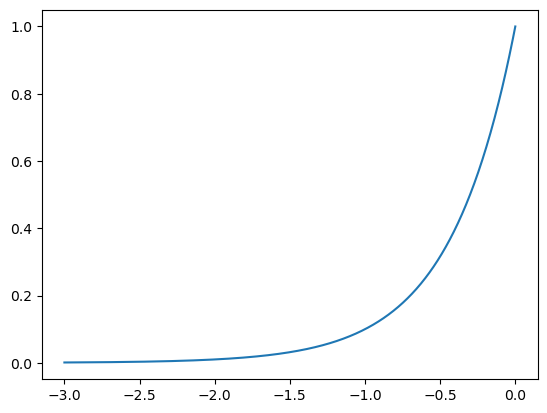

In [19]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre
plt.plot(lre.to('cpu'), lrs.to('cpu'))

In [20]:
lri = []
lossi = []
for i in range(1000):
    # mini-batch construct
    ix = torch.randint(0, X.shape[0], (32, ))

    # forward pass
    # C[X] for every element in X, pull the embedding in C
    # imagine the matrix being stretched with the embeddings
    # X - (32, 3) -> C(X) - (32, 3, 2)
    emb = C[X[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = lrs[i]
    for p in parameters:
        # we can also consider other learning rates
        p.data += -lr * p.grad
    
    # track stats
    lri.append(lre[i].item())
    lossi.append(loss.item())
# print(loss.item())


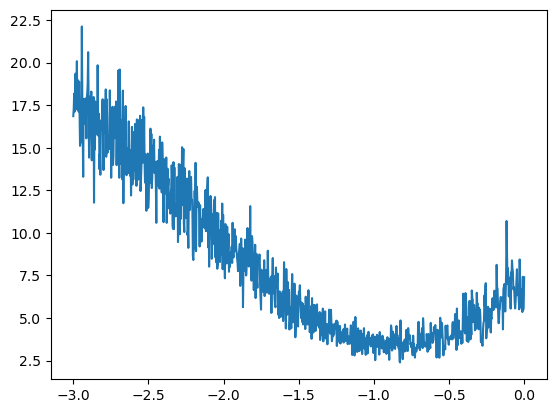

In [21]:
plt.plot(lri, lossi)

In [ ]:
# Optimal learning rate b/w exponents -1 and -0.5